## Demo for modelling single-channel PSF from bead data

#### Setup environment

In [1]:
import sys
sys.path.append("..")
from psflearning.psflearninglib import psflearninglib
from psflearning import io
from psflearning.makeplots import *
import tensorflow as tf
#main_data_dir = io.param.load('datapath.yaml').main_data_dir
try:
    gpus = tf.config.list_physical_devices('GPU')
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print('Running on GPU')
except:
    print('Running on CPU')

Running on GPU


#### Create psflearning object and load the config file
$\small\color{skyblue}{\mathrm{basefile}}$: config file with all parameters  
$\small\color{skyblue}{\mathrm{psftype}}$:  `'voxel', 'zernike'`  
$\small\color{skyblue}{\mathrm{sysfile}}$: config file with microscope specific parameters  
For advanced user, pass in base file only as below to interact with all parameters:   
```python
    L.param = io.param.combine('config_user')
```

In [2]:
L = psflearninglib()
L.param = io.param.combine('config_base',psftype='insitu',channeltype='2ch',sysfile='smart_tirf')


#### Edit user defined parameters

In [3]:
L.param.datapath = r'T:\projects\cells-labeling\Data\DNA PAINT smart\7_22_25\2025-07-22/'
L.param.keyword = 'Cell2_Hek293_AlfaEGFR_WT_ALFA15pM_laser100percent--2025-07-22_17-21-22' # keyword for your data file
L.param.savename = L.param.datapath+'python/result_2ch/' + L.param.keyword
L.param.subfolder = '' # keyword for subfolder name if each data file is saved in a individual folder, set to '' if no subfolder
L.param.gain = 0.24
L.param.ccd_offset = 100
L.param.ref_channel = 0 # choose the brighter channel as the reference channel, 0 or 1
L.param.batch_size = 500 # lower this number if out of memory
L.param.option.imaging.emission_wavelength = 0.68 # micron
L.param.varname = 'Main/data'
L.param.option.insitu.stage_pos = 0.8
L.param.option.model.n_max = 6
L.param.option.insitu.z_range = 1.0
L.param.option.insitu.repeat=2
L.param.option.insitu.stage_tilt = [0,0]
L.param.insitu.frame_range = [1000,1500]
L.param.option.model.const_pupilmag = True
L.param.option.insitu.var_stagepos = False
L.param.plotall = True

#### Start learning

In [4]:
images = L.load_data()

T:\projects\cells-labeling\Data\DNA PAINT smart\7_22_25\2025-07-22\Cell2_Hek293_AlfaEGFR_WT_ALFA15pM_laser100percent--2025-07-22_17-21-22.h5
(2, 500, 420, 256)


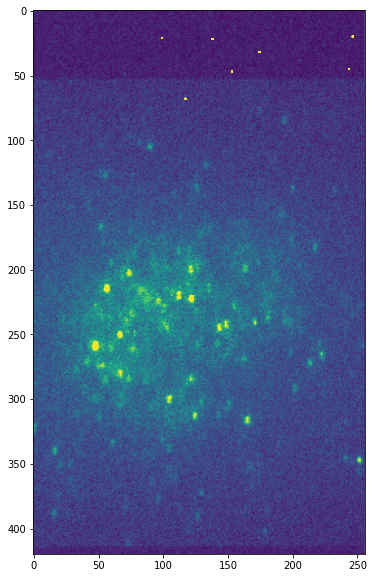

In [5]:
plt.figure(figsize=(10, 10))
plt.imshow(images[1][0],clim=(0, np.quantile(images,0.999)))

Image size: (256, 256)


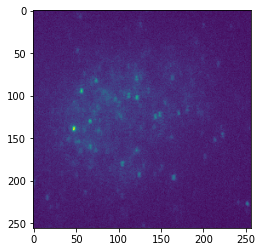

In [6]:
imsz = 256
startx = 0
starty = 120
plt.imshow(images[1][0][starty:starty+imsz,startx:startx+imsz])
print('Image size:', images[0][0][starty:starty+imsz,startx:startx+imsz].shape)

In [7]:
L.param.FOV.startx = startx
L.param.FOV.starty = starty
L.param.FOV.imsz = imsz
images = images[:,:,starty:starty+imsz,startx:startx+imsz]

rois shape channel 0: (2012, 15, 15)
rois shape channel 1: (1982, 15, 15)


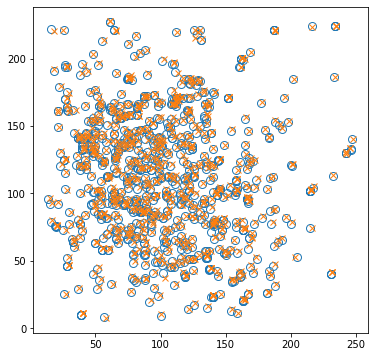

rois shape channel 0: (869, 15, 15)
rois shape channel 1: (869, 15, 15)


In [8]:
L.getpsfclass()
L.param.roi.roi_size = [15,15]
L.param.roi.peak_height = 0.5
dataobj = L.prep_data(images)

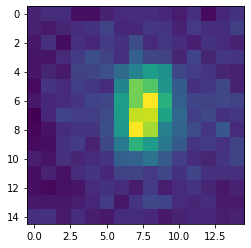

In [9]:
plt.imshow(dataobj.channels[1].rois[0])

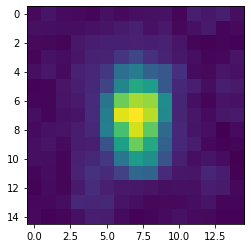

In [10]:
plt.imshow(np.max(dataobj.channels[1].rois, axis=0))

4/6: calculating spline coefficients: 1/1 [00:00s]  2.50it/s total time: 0.40s
5/6: localization: 2/2 [00:00s]  7.61it/s total time: 0.66s
4/6: calculating spline coefficients: 1/1 [00:00s]  2.65it/s total time: 1.04s
5/6: localization: 2/2 [00:00s] 35.15it/s total time: 1.09s
4/6: calculating spline coefficients: 1/1 [00:00s]  2.74it/s total time: 1.45s
5/6: localization: 2/2 [00:00s] 38.43it/s total time: 1.50s
4/6: calculating spline coefficients: 1/1 [00:00s]  2.55it/s total time: 1.89s
5/6: localization: 2/2 [00:00s] 34.76it/s total time: 1.95s
4/6: calculating spline coefficients: 1/1 [00:00s]  2.60it/s total time: 2.32s
5/6: localization: 2/2 [00:00s] 22.00it/s total time: 2.41s
4/6: calculating spline coefficients: 1/1 [00:00s]  2.65it/s total time: 2.78s
5/6: localization: 2/2 [00:00s] 24.30it/s total time: 2.86s
4/6: calculating spline coefficients: 1/1 [00:00s]  2.69it/s total time: 3.23s
5/6: localization: 2/2 [00:00s] 27.63it/s total time: 3.31s
4/6: calculating spline coe

outlier percentage: 0.25236593059936907
rois shape channel 0: (237, 15, 15)
rois shape channel 1: (237, 15, 15)


3/6: learning: 186/250 [00:41s]  4.49it/s, current loss: 1.57329, total time: 111.52s
4/6: calculating spline coefficients: 2/2 [00:00s]  2.52it/s total time: 0.78s
5/6: localization: 2/2 [00:00s]  2.05it/s total time: 1.75s
6/6: saving results: [00:01s] total time: 3.23s


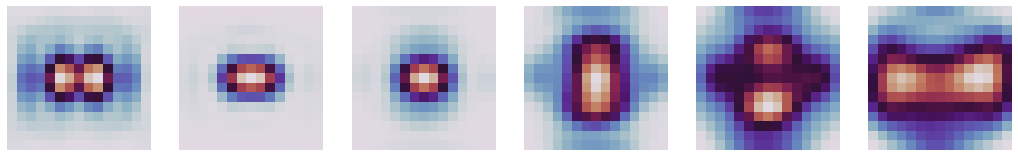

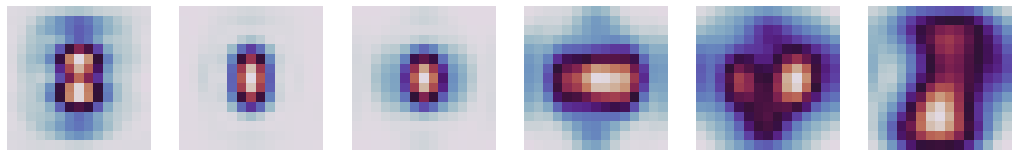

4/6: calculating spline coefficients: 1/1 [00:00s]  2.74it/s total time: 0.37s
5/6: localization: 2/2 [00:00s]  6.64it/s total time: 0.66s
3/6: learning: 54/100 [00:11s]  4.51it/s, current loss: 0.82600, total time: 11.97s
4/6: calculating spline coefficients: 1/1 [00:00s]  2.70it/s total time: 12.34s
5/6: localization: 2/2 [00:00s] 15.36it/s total time: 12.47s
3/6: learning: 57/100 [00:12s]  4.48it/s, current loss: 0.94967, total time: 24.67s
4/6: calculating spline coefficients: 2/2 [00:00s]  2.64it/s total time: 0.75s
5/6: localization: 2/2 [00:00s]  4.20it/s total time: 1.22s
3/6: learning: 205/250 [00:45s]  4.47it/s, current loss: 1.74830, total time: 70.57s


outlier percentage: 0.24232081911262804
rois shape channel 0: (222, 15, 15)
rois shape channel 1: (222, 15, 15)


3/6: learning: 210/250 [00:46s]  4.52it/s, current loss: 1.56908, total time: 116.99s
4/6: calculating spline coefficients: 2/2 [00:00s]  2.57it/s total time: 0.77s
5/6: localization: 2/2 [00:00s]  2.23it/s total time: 1.67s
6/6: saving results: [00:01s] total time: 3.11s


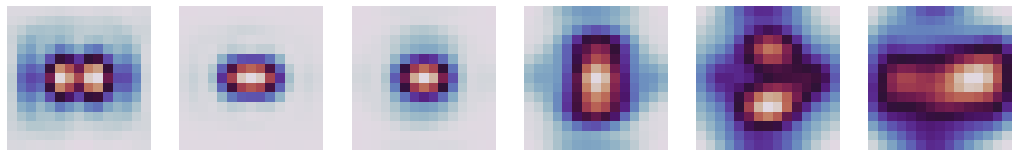

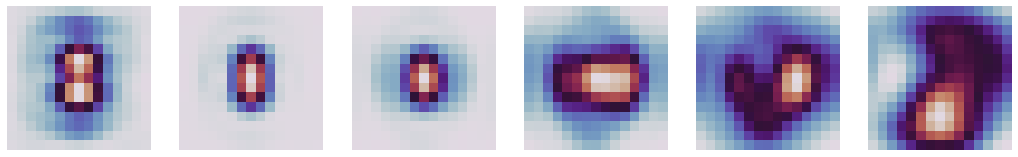

In [11]:
resfile = L.iterlearn_psf(dataobj,time=0)

#### Show results

In [12]:
f,p = io.h5.load(resfile) # load result file

channel 0


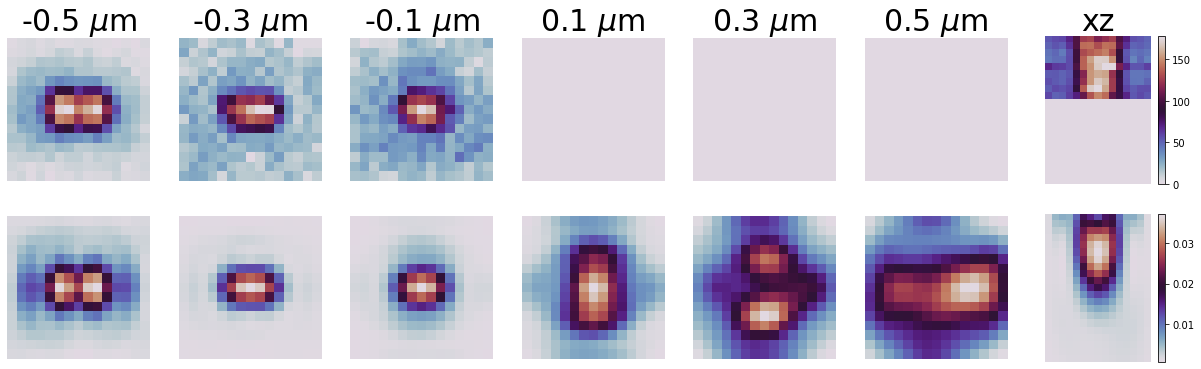

channel 1


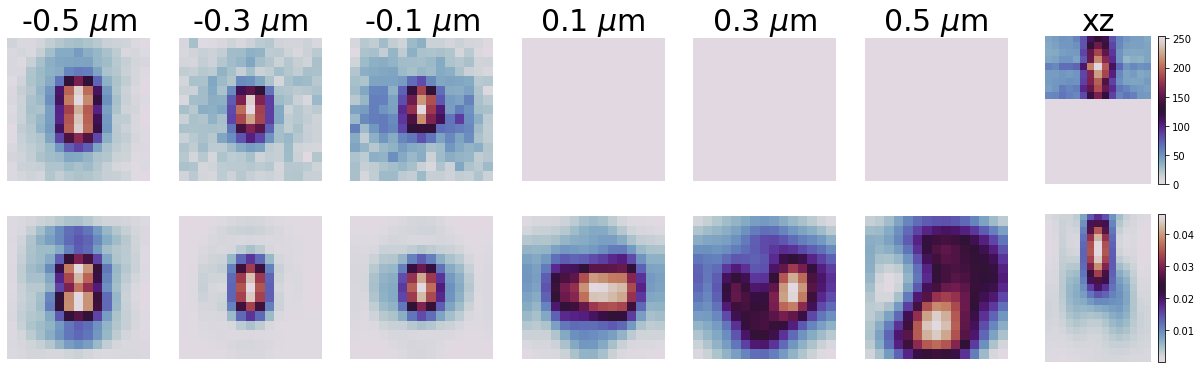

In [13]:
showpsfvsdata_insitu(f,p)

In [15]:
f.res.channel1.stagepos

array([0.8536932], dtype=float32)

In [16]:
[f.res.channel0.sigma,f.res.channel1.sigma]

[array([0.46532473, 0.3965683 ], dtype=float32),
 array([0.4301078 , 0.36561882], dtype=float32)]

#### Optional plots

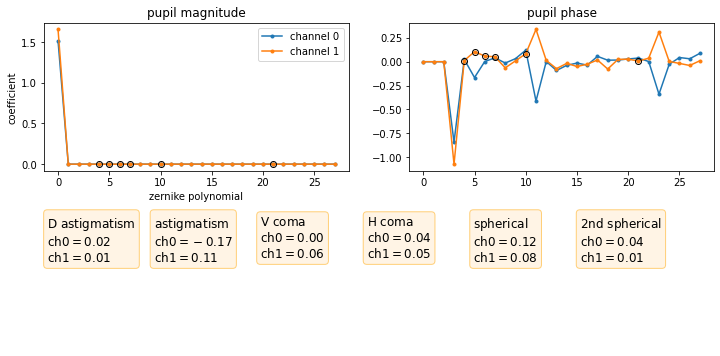

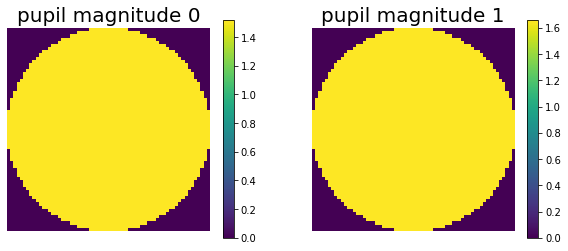

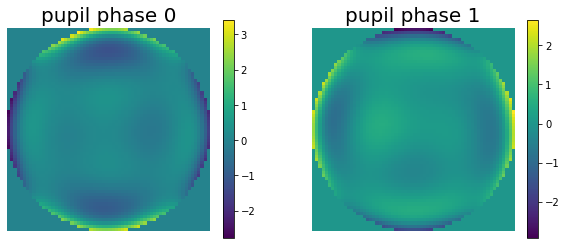

In [17]:
try:
    showzernike(f,p)
except:
    try: 
        showpupil(f,p)
    except:
        print('no pupil')

[[ 0.9979 -0.0017 -0.    ]
 [ 0.0011  0.9971  0.    ]
 [18.2101 -7.7131  1.    ]]


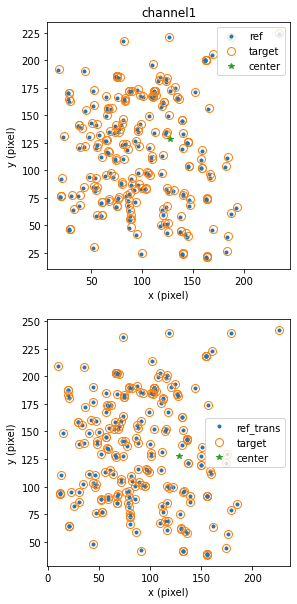

In [18]:
showtransform(f)
np.set_printoptions(precision=4,suppress=True)
print(f.res.T)

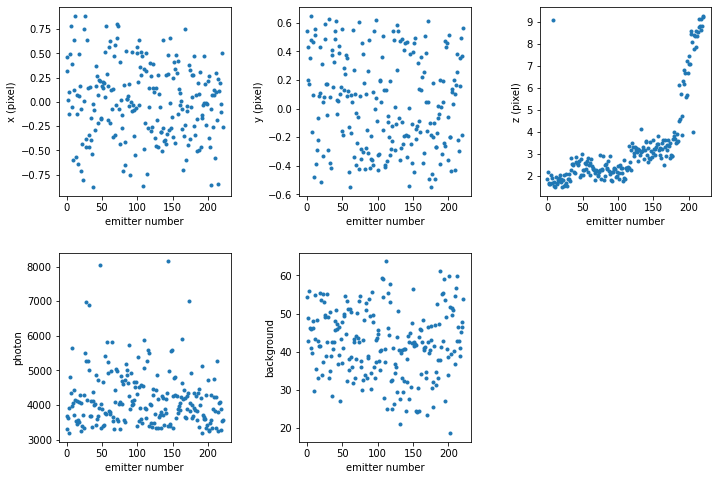

In [19]:
showlearnedparam_insitu(f,p)

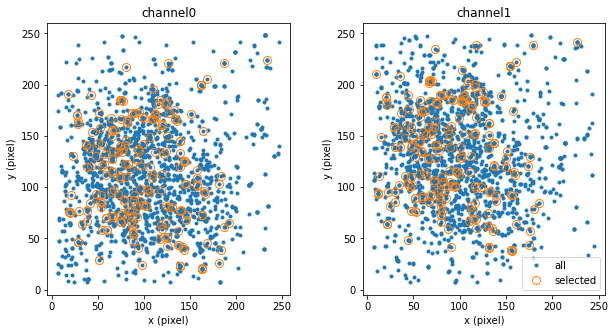

In [20]:
showcoord(f,p)

#### Ouput parameters

In [11]:
print('f:\n    ',list(f.keys()))
print(' locres:\n    ',list(f.locres.keys()))
print(' res:\n    ',list(f.res.keys()))
print(' rois:\n    ',list(f.rois.keys()))

f:
     ['locres', 'res', 'rois']
 locres:
     ['CRLB', 'LL', 'P', 'coeff', 'coeff_bead', 'coeff_reverse', 'loc']
 res:
     ['I_model', 'I_model_bead', 'I_model_reverse', 'apodization', 'bg', 'cor', 'cor_all', 'drift_rate', 'intensity', 'offset', 'pos', 'pupil', 'sigma', 'zernike_coeff', 'zernike_polynomial']
 rois:
     ['cor', 'fileID', 'image_size', 'psf_data', 'psf_fit']
